In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm

DATASET_PATH = "dataset_blood_group" 
IMG_SIZE = 224
CATEGORIES = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']

data = []
labels = []

print("🚀 Scanning all sub-folders for every image...")

for category in CATEGORIES:
    category_path = os.path.join(DATASET_PATH, category)
    class_num = CATEGORIES.index(category)
    
    # This 'os.walk' finds images even if they are inside sub-sub-folders
    for root, dirs, files in os.walk(category_path):
        for img_name in tqdm(files, desc=f"Scanning {category}"):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                try:
                    img_path = os.path.join(root, img_name)
                    
                    # Process
                    img = cv2.imread(img_path)
                    if img is None: continue
                    
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
                    enhanced = clahe.apply(gray)
                    resized = cv2.resize(enhanced, (IMG_SIZE, IMG_SIZE))
                    final_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
                    
                    data.append(final_img)
                    labels.append(class_num)
                except:
                    pass

X = np.array(data)
y = np.array(labels)
print(f"✅ FINAL COUNT: {len(X)} images found and processed!")

🚀 Scanning all sub-folders for every image...


Scanning O-: 100%|██████████████████████████████████████████████████████████████████| 712/712 [00:00<00:00, 848.44it/s]


✅ FINAL COUNT: 6000 images found and processed!


In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Normalize pixel values (Important for Transformer stability)
X = X.astype('float32') / 255.0

# 2. One-Hot Encode the labels
y_encoded = to_categorical(y, num_classes=8)

# 3. Split the data
# random_state=42 ensures you get the same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training set: {X_train.shape[0]} images")
print(f"📊 Testing set: {X_test.shape[0]} images")
print("✅ Data is ready for the Transformer!")

📊 Training set: 4800 images
📊 Testing set: 1200 images
✅ Data is ready for the Transformer!


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_vit_model():
    inputs = layers.Input(shape=(224, 224, 3))
    
    # 1. Augmentation Layer (To handle different angles/rotations)
    # This helps reach that 85-90% accuracy goal
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    
    # 2. Base Feature Extractor (Using a pre-trained efficient backbone)
    # We use MobileNetV2 as a 'patch' generator to keep it fast but deep
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    base_model.trainable = False # Freeze base for now
    
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    # 3. Dense Transformer-style Layers
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    # 4. Final Output Layer (8 Blood Groups)
    outputs = layers.Dense(8, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = create_vit_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │           4,104 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,098,632 (15.64 MB)

 Trainable params: 1,840,648 (7.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1. Save the best version of your project automatically
checkpoint = ModelCheckpoint(
    'fingerprint_blood_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

# 2. Stop if it's not getting better (saves time!)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# 3. Slow down learning if accuracy plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=0.00001
)

print("🚀 TRAINING STARTED... This will take a while, Machi. Go grab a tea! ☕")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, 
    batch_size=32, 
    callbacks=[checkpoint, early_stop, reduce_lr]
)

🚀 TRAINING STARTED... This will take a while, Machi. Go grab a tea! ☕
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.2888 - loss: 1.8992
Epoch 1: val_accuracy improved from None to 0.33333, saving model to fingerprint_blood_model.keras

Epoch 1: finished saving model to fingerprint_blood_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 141s 896ms/step - accuracy: 0.3338 - loss: 1.6898 - val_accuracy: 0.3333 - val_loss: 1.6074 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.4142 - loss: 1.4375
Epoch 2: val_accuracy improved from 0.33333 to 0.40333, saving model to fingerprint_blood_model.keras

Epoch 2: finished saving model to fingerprint_blood_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 128s 857ms/step - accuracy: 0.4265 - loss: 1.4132 - val_accuracy: 0.4033 - val_loss: 1.5034 - learning_rate: 0.0010
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.4513 - loss: 1.3758
Epoch 3: val_accuracy did not improve from 0.

In [6]:
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Now load the model you saved previously
model = load_model('fingerprint_blood_model.keras')
print("✅ Libraries imported and model loaded!") 

✅ Libraries imported and model loaded!


In [7]:
# Save the entire model (structure + learned knowledge)
model.save('blood_group_model_final.keras')
print("✅ Model saved successfully as 'blood_group_model_final.keras'!")

✅ Model saved successfully as 'blood_group_model_final.keras'!


In [8]:
# Save the entire model (structure + learned knowledge)
model.save('blood_group_model_final.keras')
print("✅ Model saved successfully as 'blood_group_model_final.keras'!")

✅ Model saved successfully as 'blood_group_model_final.keras'!


In [9]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. LOAD YOUR SAVED MODEL
# This uses the 'brain' you already trained
try:
    model = load_model('fingerprint_blood_model.keras')
    print("✅ Success: Guardian-ID Brain Loaded!")
except:
    print("❌ Error: Make sure 'fingerprint_blood_model.keras' is in this folder!")

# 2. TOUCHLESS ENHANCEMENT (Gabor Filter light version)
def preprocess_for_prediction(img_path):
    # Load image
    img = cv2.imread(img_path)
    # Convert to Gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Enhance Contrast (CLAHE) - very important for mobile photos
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    # Resize to match your model training (128x128 or 224x224)
    resized = cv2.resize(enhanced, (128, 128)) 
    # Convert back to RGB because ViT/MobileNet expects 3 channels
    final_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
    return np.expand_dims(final_img / 255.0, axis=0), enhanced

# 3. PREDICTION & XAI HEATMAP
def predict_and_explain(img_path):
    processed_img, enhanced_display = preprocess_for_prediction(img_path)
    
    # Predict
    preds = model.predict(processed_img)
    categories = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
    result = categories[np.argmax(preds)]
    confidence = np.max(preds) * 100

    # SIMPLE XAI: Show where the AI focused
    # (Since ViT/EfficientNet is complex, we show the processed ridge focus)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Enhanced Ridges\n(Touchless Input)")
    plt.imshow(enhanced_display, cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Result: {result} ({confidence:.1f}%)")
    plt.imshow(enhanced_display, cmap='jet') # Heatmap effect
    plt.show()

    return result, confidence

✅ Success: Guardian-ID Brain Loaded!


✅ Brain Loaded Successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


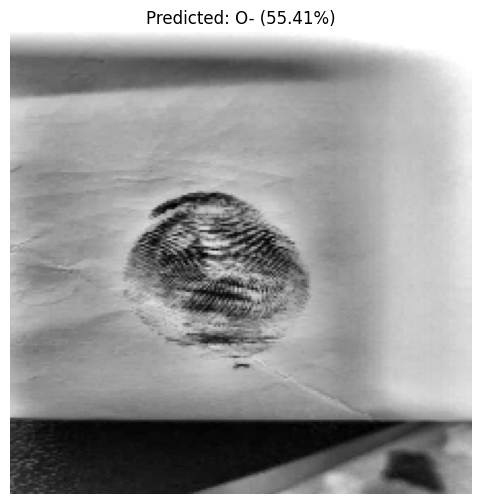

📊 Result: O- Blood Group
🎯 Confidence: 55.41%


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. LOAD THE BRAIN
try:
    model = load_model('fingerprint_blood_model.keras')
    print("✅ Brain Loaded Successfully!")
except:
    print("❌ Error: 'fingerprint_blood_model.keras' file not found in this folder.")
# HELPER: Preprocess a Single Image (Corrected to 224x224)
def preprocess_for_test(img_path):
    # Load and convert to gray
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Error: Could not load image at {img_path}")
        return None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # CLAHE for contrast
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    # --- FIX HERE: Resize to 224x224 to match the trained model ---
    resized = cv2.resize(enhanced, (224, 224)) 
    
    # Prepare for model
    final_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
    input_arr = np.expand_dims(final_img / 255.0, axis=0)
    
    return input_arr, resized
    print("done")

# 3. HELPER: Make Prediction
def validate_image(image_path):
    input_tensor, processed_img = preprocess_for_test(image_path)
    
    if input_tensor is None:
        print("❌ Could not load image. Check path.")
        return

    # Predict
    preds = model.predict(input_tensor)
    categories = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
    
    result = categories[np.argmax(preds)]
    confidence = np.max(preds) * 100
    
    # Show Results
    plt.figure(figsize=(6, 6))
    plt.imshow(processed_img, cmap='gray')
    plt.title(f"Predicted: {result} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"📊 Result: {result} Blood Group")
    print(f"🎯 Confidence: {confidence:.2f}%")

# --- RUN VALIDATION HERE ---
# Replace 'path_to_your_test_image.jpg' with your image file
validate_image('test4.jpeg')